# Stage 1: PneumoniaMNIST Baseline and Controlled Image-Shift Experiment

## Research objective

This notebook is the starting point of the experiment.

The first part establishes a simple convolutional neural network (CNN) baseline on PneumoniaMNIST. The aim is not to build a state-of-the-art medical imaging model. Instead, the model gives us a controlled setting in which we can study both classification performance and the quality of the confidence scores produced by the model.

The second part introduces a simple, controlled change to the test images by reducing their contrast. The trained model is kept unchanged. This allows us to examine how a change in image appearance affects the model's predictions and confidence.

The notebook therefore has two main parts:

1. Baseline training and calibration analysis on PneumoniaMNIST.
2. Controlled reduced-contrast evaluation of the same trained model.

The trained model is later reused in the external RSNA evaluation in Stage 2.


In [1]:
pip install -r requirements_stage1.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1. Import the libraries

We first install the project requirements and import the libraries needed for the experiment.

I am keeping the imports close to the beginning so that the rest of the notebook can be read from top to bottom without having to look for dependencies later.


In [2]:
# NumPy helps us work with numbers and arrays.
import numpy as np

# Matplotlib is used to display the X-ray images and later
# create charts such as reliability diagrams.
import matplotlib.pyplot as plt

# PyTorch is the machine-learning framework we will use
# to build and train our neural network.
import torch
import torch.nn as nn

# DataLoader helps us feed the images to the model in
# small groups, called batches, during training.
from torch.utils.data import DataLoader

# torchvision provides common image-processing tools.
from torchvision import transforms

# MedMNIST provides the PneumoniaMNIST medical-imaging dataset.
from medmnist import PneumoniaMNIST

# Counter will help us count how many normal and pneumonia
# images are present in each dataset split.
from collections import Counter

# 2. Set the random seed and select the device

Before loading the data, I set a fixed random seed. This makes the experiment easier to reproduce because operations involving randomness should behave consistently between runs.

I also check whether a CUDA-enabled NVIDIA GPU is available. If it is not available, PyTorch automatically uses the CPU.


In [3]:
# Setting a random seed makes the experiment more reproducible.
# This means that random operations will behave more consistently
# when we run the notebook again.
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

# Check whether a CUDA-enabled NVIDIA GPU is available.
# Your current environment reported CUDA=False, so this experiment
# will run on your CPU. That is completely fine for this small model.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Using device:", device)

PyTorch version: 2.5.1+cpu
Using device: cpu


# 3. Load the PneumoniaMNIST dataset

The next step is to load the training, validation, and test splits.

The training set is used to learn the model parameters. The validation set is used while developing and checking the model. The test set is kept untouched until the final baseline evaluation.


In [4]:
# Convert each X-ray image into a PyTorch tensor.
# A tensor is simply the numerical representation that PyTorch
# uses to perform calculations on an image.
transform = transforms.ToTensor()


# Load the training dataset.
# The training data are the images the neural network is allowed
# to learn from.
train_ds = PneumoniaMNIST(
    split="train",
    download=True,
    transform=transform,
    size=64
)


# Load the validation dataset.
# We will use this data later to check the model during development
# and to learn the temperature-scaling parameter.
# It will NOT be used as the final test result.
val_ds = PneumoniaMNIST(
    split="val",
    download=True,
    transform=transform,
    size=64
)


# Load the test dataset.
# This dataset will remain untouched while we train the model.
# It will only be used for our final evaluation.
test_ds = PneumoniaMNIST(
    split="test",
    download=True,
    transform=transform,
    size=64
)


# Print some basic information so we can confirm that
# the dataset was loaded correctly.
print("Training images:", len(train_ds))
print("Validation images:", len(val_ds))
print("Test images:", len(test_ds))

print("Task:", train_ds.info["task"])
print("Labels:", train_ds.info["label"])

Using downloaded and verified file: C:\Users\PRASAD\.medmnist\pneumoniamnist_64.npz
Using downloaded and verified file: C:\Users\PRASAD\.medmnist\pneumoniamnist_64.npz
Using downloaded and verified file: C:\Users\PRASAD\.medmnist\pneumoniamnist_64.npz
Training images: 4708
Validation images: 524
Test images: 624
Task: binary-class
Labels: {'0': 'normal', '1': 'pneumonia'}


# 4. Visually inspect example X-rays

Before training anything, I want to confirm that the dataset contains images in the format I expect.

This cell displays a small selection of X-rays together with their labels. This is a basic sanity check rather than a modelling step.


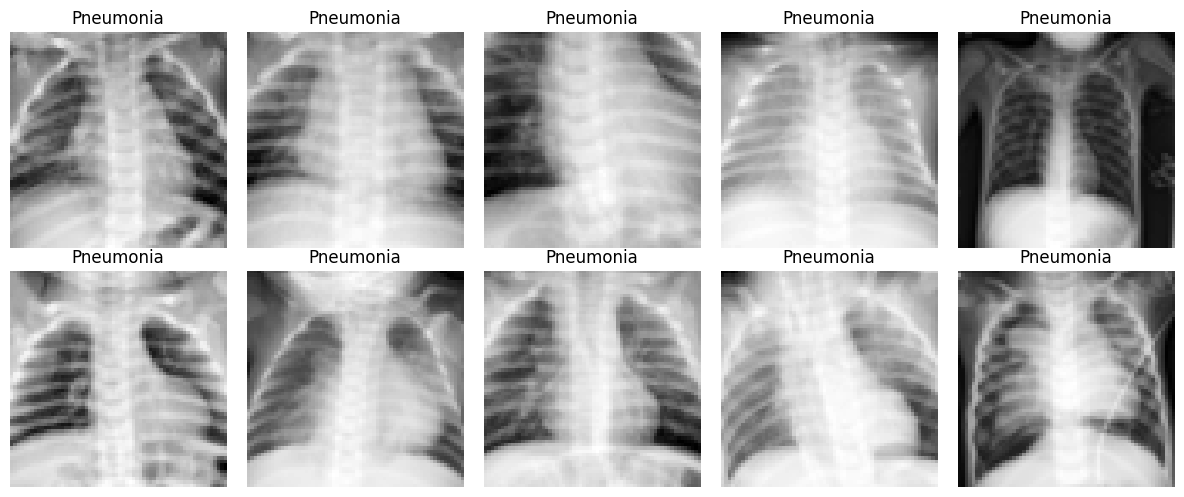

In [5]:
# Create a 2-by-5 grid so that we can look at 10 example X-rays.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))


# Go through each position in the grid.
for ax in axes.ravel():

    # Randomly select one image from the training dataset.
    idx = np.random.randint(len(train_ds))

    # Get the image and its corresponding label.
    image, label = train_ds[idx]

    # MedMNIST stores the label as a small NumPy array.
    # squeeze() removes the unnecessary dimensions so that
    # we are left with a simple number such as 0 or 1.
    label_value = int(np.asarray(label).squeeze())

    # Display the X-ray as a grayscale image.
    ax.imshow(image.squeeze(), cmap="gray")

    # Convert the numerical label into a human-readable name.
    ax.set_title(
        "Pneumonia" if label_value == 1 else "Normal"
    )

    # We don't need axis numbers for medical images,
    # so we hide them to keep the figure easier to read.
    ax.axis("off")


# Adjust the spacing so that the images and titles do not overlap.
plt.tight_layout()

# Display the finished figure.
plt.show()

# 5. Check the class distribution

Because this is a medical classification problem, I also check how many examples belong to each class in each split.

This gives context for the later accuracy, precision, recall, and calibration results.


In [6]:
# Extract the labels from the training dataset.
# We convert each label into a normal Python integer so that
# Counter can easily count the two classes.
train_labels = [
    int(np.asarray(train_ds[i][1]).squeeze())
    for i in range(len(train_ds))
]


# Do the same for the validation dataset.
val_labels = [
    int(np.asarray(val_ds[i][1]).squeeze())
    for i in range(len(val_ds))
]


# And finally, count the labels in the test dataset.
test_labels = [
    int(np.asarray(test_ds[i][1]).squeeze())
    for i in range(len(test_ds))
]


# Count how many examples belong to each class.
train_counts = Counter(train_labels)
val_counts = Counter(val_labels)
test_counts = Counter(test_labels)


# Display the results.
print("Training:", train_counts)
print("Validation:", val_counts)
print("Test:", test_counts)

Training: Counter({1: 3494, 0: 1214})
Validation: Counter({1: 389, 0: 135})
Test: Counter({1: 390, 0: 234})


# 6. Create the DataLoaders

The DataLoaders divide the datasets into batches.

The training loader shuffles the training examples, while the validation and test loaders keep a fixed order because they are only being used for evaluation.


In [7]:
# A batch is a small group of images processed together.
# Using batches is much more practical than sending all 4,708
# training images through the model at once.
BATCH_SIZE = 64


# The training DataLoader shuffles the training images.
# This prevents the model from seeing the training examples
# in exactly the same order during every epoch.
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)


# Validation data does not need to be shuffled because
# we are only measuring the model's performance on it.
val_loader = DataLoader(
    val_ds,
    batch_size=128,
    shuffle=False
)


# The test set also remains in a fixed order.
# Remember: we will not use it while training the model.
test_loader = DataLoader(
    test_ds,
    batch_size=128,
    shuffle=False
)


print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 74
Validation batches: 5
Test batches: 5


# 7. Define the baseline SmallCNN

I use a deliberately small convolutional neural network for this first experiment.

The important point here is consistency. This same architecture is trained in Stage 1 and later reused for the external RSNA evaluation in Stage 2.


In [8]:
class SmallCNN(nn.Module):
    """
    A small convolutional neural network for binary
    chest X-ray classification.

    The purpose of this model is not to achieve state-of-the-art
    medical-image performance. It gives us a simple model whose
    predictions and confidence scores we can study.
    """

    def __init__(self):
        super().__init__()

        # Convolutional layers look for visual patterns in the X-ray.
        #
        # The first layer learns simple patterns such as edges
        # and basic shapes.
        #
        # The later layers can combine these into more complex
        # patterns useful for classification.
        self.features = nn.Sequential(

            # Input: one grayscale image channel.
            # Output: 16 learned feature maps.
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            # ReLU introduces non-linearity so the network
            # can learn more complex relationships.
            nn.ReLU(),

            # Reduce the spatial size of the image.
            # This keeps the model smaller and reduces computation.
            nn.MaxPool2d(2),


            # Take the 16 feature maps from the previous layer
            # and learn 32 more detailed feature maps.
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),


            # Learn a larger set of higher-level image features.
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),


            # Reduce each feature map to a single representative value.
            # This gives us a compact representation of the image.
            nn.AdaptiveAvgPool2d(1)
        )


        # The final layer converts the 64 learned features
        # into one number called a logit.
        #
        # A positive logit generally indicates stronger evidence
        # for pneumonia, while a negative logit indicates stronger
        # evidence for normal.
        self.classifier = nn.Linear(64, 1)


    def forward(self, x):

        # Pass the image through the convolutional layers.
        x = self.features(x)

        # Flatten the extracted features so that they can
        # be passed into the final classification layer.
        x = x.flatten(1)

        # Produce the final prediction score.
        return self.classifier(x).squeeze(1)

# 8. Create the model, loss function, and optimizer

Now I create the model and define the two main components needed for training:

- Binary cross-entropy with logits as the loss function.
- Adam as the optimizer.

At this point the model has not learned from the training images yet.


In [9]:
# Create our neural network and move it to the device
# selected earlier, which in your case is the CPU.
model = SmallCNN().to(device)


# BCEWithLogitsLoss is suitable for binary classification.
#
# It combines two operations:
# 1. converting the model's raw score into a probability-like value
# 2. calculating how different that prediction is from the true label
#
# We are starting with the basic loss function because this is
# our baseline experiment.
criterion = nn.BCEWithLogitsLoss()


# Adam is the algorithm that adjusts the model's internal parameters
# during training so that its predictions gradually improve.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


# Display the model so that we can see its structure.
print(model)

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Linear(in_features=64, out_features=1, bias=True)
)


# 9. Train the baseline model

The model is now trained for five epochs.

For each epoch, the notebook first updates the model using the training data and then measures the validation loss without changing the model parameters.

Keeping the training and validation steps separate makes it possible to see whether the model is learning the training data while still behaving reasonably on unseen validation images.


In [10]:
# We start with only five complete passes through the training data.
# This keeps the first experiment reasonably quick on your CPU.
NUM_EPOCHS = 5


# Store the training and validation losses so that we can
# examine how the model behaves during training.
training_losses = []
validation_losses = []


# Repeat the training process for each epoch.
for epoch in range(NUM_EPOCHS):

    # ---------------------------------------------------------
    # TRAINING PHASE
    # ---------------------------------------------------------

    # Put the model into training mode.
    # This tells PyTorch that we are currently learning from
    # the training data.
    model.train()

    total_train_loss = 0.0


    # Process the training data batch by batch.
    for images, labels in train_loader:

        # Move the images to our selected device.
        images = images.to(device)

        # Convert the labels to floating-point numbers because
        # BCEWithLogitsLoss expects floating-point targets.
        labels = labels.float().to(device).squeeze()


        # Remove the gradients calculated during the previous
        # training step.
        #
        # PyTorch otherwise accumulates gradients from one step
        # into the next, which is not what we want here.
        optimizer.zero_grad()


        # Ask the neural network to make predictions for this batch.
        logits = model(images)


        # Compare the model's predictions with the known labels.
        loss = criterion(logits, labels)


        # Calculate how each model parameter contributed to the error.
        loss.backward()


        # Use those gradients to update the model's parameters.
        optimizer.step()


        # Keep track of the loss so that we can calculate
        # the average training loss for the whole epoch.
        total_train_loss += loss.item() * images.size(0)


    # Calculate the average training loss across all images.
    average_train_loss = (
        total_train_loss / len(train_loader.dataset)
    )


    # ---------------------------------------------------------
    # VALIDATION PHASE
    # ---------------------------------------------------------

    # Put the model into evaluation mode.
    # We are not changing the model here. We are simply checking
    # how it behaves on data it did not train on.
    model.eval()

    total_val_loss = 0.0


    # Tell PyTorch that we do not need gradients during validation.
    # This saves memory and makes the calculation faster.
    with torch.no_grad():

        for images, labels in val_loader:

            # Move the validation images to the selected device.
            images = images.to(device)

            # Convert the labels to the format expected by the loss.
            labels = labels.float().to(device).squeeze()

            # Ask the model for predictions.
            logits = model(images)

            # Calculate the validation loss.
            loss = criterion(logits, labels)

            # Add this batch's contribution to the total.
            total_val_loss += loss.item() * images.size(0)


    # Calculate the average validation loss.
    average_val_loss = (
        total_val_loss / len(val_loader.dataset)
    )


    # Save both losses so we can plot them later.
    training_losses.append(average_train_loss)
    validation_losses.append(average_val_loss)


    # Display the progress after each epoch.
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Training Loss: {average_train_loss:.4f} | "
        f"Validation Loss: {average_val_loss:.4f}"
    )

Epoch 1/5 | Training Loss: 0.5903 | Validation Loss: 0.5673
Epoch 2/5 | Training Loss: 0.5669 | Validation Loss: 0.5596
Epoch 3/5 | Training Loss: 0.5509 | Validation Loss: 0.5460
Epoch 4/5 | Training Loss: 0.5207 | Validation Loss: 0.4934
Epoch 5/5 | Training Loss: 0.4845 | Validation Loss: 0.4497


# 10. Plot training and validation loss

After training, I plot the training and validation losses across the five epochs.

This provides a simple visual check of how the optimisation progressed.


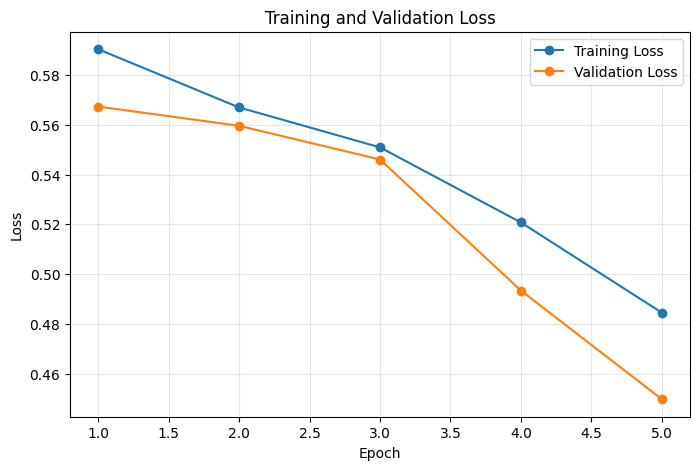

In [11]:
# Create a simple chart showing how the training and validation
# losses changed over the five epochs.
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    training_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    validation_losses,
    marker="o",
    label="Validation Loss"
)


# Label the chart so that somebody unfamiliar with the experiment
# can understand what is being shown.
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 11. Save the trained Stage 1 model

The model has now finished training, so this is the correct point to save its learned parameters.

The checkpoint is saved under the same project structure that Stage 2 will use:

`D:\0001_Kings_AI_Project\trustworthy-ai-medical-imaging\models\smallcnn_pneumoniamnist_stage1.pt`

Saving the checkpoint here is important because Stage 2 is a separate notebook. It needs to evaluate this exact trained model rather than creating a new randomly initialised network.


In [12]:
# ---------------------------------------------------------
# SAVE THE TRAINED STAGE 1 MODEL
# ---------------------------------------------------------
#
# We save the trained model after the five training epochs.
# This is important because Stage 2 is a separate notebook.
# Stage 2 needs to use exactly the same trained CNN rather
# than creating a new randomly initialised model.
#
# Only the learned weights are saved. The model architecture
# itself will be recreated in Stage 2 using the same SmallCNN
# definition.

from pathlib import Path


# Create a dedicated folder for model checkpoints.
checkpoint_dir = Path(
    r"D:\0001_Kings_AI_Project\trustworthy-ai-medical-imaging\models"
)

checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True
)


# Define the checkpoint filename.
checkpoint_path = (
    checkpoint_dir /
    "smallcnn_pneumoniamnist_stage1.pt"
)


# Save the trained model parameters.
torch.save(
    model.state_dict(),
    checkpoint_path
)


print("Stage 1 model saved successfully.")
print("Checkpoint:", checkpoint_path)
print("File exists:", checkpoint_path.exists())

Stage 1 model saved successfully.
Checkpoint: D:\0001_Kings_AI_Project\trustworthy-ai-medical-imaging\models\smallcnn_pneumoniamnist_stage1.pt
File exists: True


# 12. Collect validation and test predictions

The trained model is now used to generate predictions for the validation and untouched test sets.

I keep the raw logits, probabilities, and ground-truth labels. The raw logits are retained because they are needed later for temperature scaling.


In [13]:
def collect_predictions(model, data_loader):
    """
    Run the trained model over a dataset and collect its predictions.

    We keep three things:
    - logits: the model's raw output before converting it to a probability
    - probabilities: the model's estimated probability of pneumonia
    - labels: the actual answer provided by the dataset

    Keeping the raw logits is important because we will need them
    later when we perform temperature scaling.
    """

    # Put the model into evaluation mode because we are no longer
    # changing its parameters.
    model.eval()

    all_logits = []
    all_probabilities = []
    all_labels = []

    # Disable gradient calculations because we are only making
    # predictions and do not need to update the model.
    with torch.no_grad():

        for images, labels in data_loader:

            # Move the images to the same device as the model.
            images = images.to(device)

            # Ask the model to produce its raw prediction scores.
            logits = model(images)

            # Convert the raw scores into probabilities between 0 and 1.
            # A probability close to 1 means the model is more confident
            # that the image belongs to the pneumonia class.
            probabilities = torch.sigmoid(logits)

            # Store the results on the CPU so they are easy to analyse
            # later with NumPy and scikit-learn.
            all_logits.append(logits.cpu().numpy())
            all_probabilities.append(probabilities.cpu().numpy())
            all_labels.append(labels.numpy().squeeze())


    # Combine the individual batches into one array for the
    # complete dataset.
    all_logits = np.concatenate(all_logits)
    all_probabilities = np.concatenate(all_probabilities)
    all_labels = np.concatenate(all_labels)

    return all_logits, all_probabilities, all_labels


# Collect predictions for the validation set.
val_logits, val_probabilities, val_labels = collect_predictions(
    model,
    val_loader
)


# Collect predictions for the untouched test set.
test_logits, test_probabilities, test_labels = collect_predictions(
    model,
    test_loader
)


print("Validation predictions:", len(val_probabilities))
print("Test predictions:", len(test_probabilities))

Validation predictions: 524
Test predictions: 624


# 13. Inspect individual test predictions

Before calculating aggregate metrics, I look at a few individual predictions.

This makes the model output easier to interpret and provides a quick sanity check that the predicted class and probability are being reported correctly.


In [14]:
# Show a few examples of what the model is predicting.
# The probability represents the model's estimated probability
# that the X-ray contains pneumonia.
for i in range(10):

    actual = "Pneumonia" if test_labels[i] == 1 else "Normal"

    predicted = (
        "Pneumonia"
        if test_probabilities[i] >= 0.5
        else "Normal"
    )

    print(
        f"Example {i + 1}: "
        f"Actual = {actual} | "
        f"Predicted = {predicted} | "
        f"Pneumonia probability = {test_probabilities[i]:.3f}"
    )

Example 1: Actual = Pneumonia | Predicted = Pneumonia | Pneumonia probability = 0.790
Example 2: Actual = Normal | Predicted = Pneumonia | Pneumonia probability = 0.847
Example 3: Actual = Pneumonia | Predicted = Pneumonia | Pneumonia probability = 0.772
Example 4: Actual = Normal | Predicted = Pneumonia | Pneumonia probability = 0.541
Example 5: Actual = Pneumonia | Predicted = Pneumonia | Pneumonia probability = 0.905
Example 6: Actual = Pneumonia | Predicted = Pneumonia | Pneumonia probability = 0.927
Example 7: Actual = Pneumonia | Predicted = Pneumonia | Pneumonia probability = 0.928
Example 8: Actual = Pneumonia | Predicted = Pneumonia | Pneumonia probability = 0.961
Example 9: Actual = Pneumonia | Predicted = Pneumonia | Pneumonia probability = 0.797
Example 10: Actual = Normal | Predicted = Pneumonia | Pneumonia probability = 0.690


# 14. Calculate baseline classification and probability metrics

The baseline is evaluated using accuracy, precision, recall, F1 score, AUROC, and Brier score.

The first group describes classification performance. The Brier score is included because this project is also interested in the quality of the probabilities produced by the model, not only whether the final class prediction is correct.


In [15]:
# Import the evaluation metrics we need from scikit-learn.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss
)


# Convert the model's probabilities into final class predictions.
#
# We use 0.5 as the decision threshold:
# - probability >= 0.5 -> predict pneumonia
# - probability < 0.5  -> predict normal
test_predictions = (
    test_probabilities >= 0.5
).astype(int)


# Calculate accuracy.
# This tells us what proportion of all test images
# were classified correctly.
accuracy = accuracy_score(
    test_labels,
    test_predictions
)


# Calculate precision.
# This answers:
# "When the model says pneumonia, how often is it correct?"
precision = precision_score(
    test_labels,
    test_predictions,
    zero_division=0
)


# Calculate recall.
# This answers:
# "Of all the images that actually contain pneumonia,
# how many did the model identify?"
recall = recall_score(
    test_labels,
    test_predictions,
    zero_division=0
)


# Calculate F1 score.
# F1 combines precision and recall into a single measure.
f1 = f1_score(
    test_labels,
    test_predictions,
    zero_division=0
)


# Calculate AUROC.
# This evaluates how well the model separates normal and
# pneumonia cases across different probability thresholds.
auroc = roc_auc_score(
    test_labels,
    test_probabilities
)


# Calculate the Brier score.
#
# Unlike accuracy, this uses the actual probability produced
# by the model. It therefore gives us information about whether
# the probabilities themselves are useful.
#
# Lower Brier scores indicate better probabilistic predictions.
brier = brier_score_loss(
    test_labels,
    test_probabilities
)


# Display the results in a readable format.
print("Baseline Test Results")
print("---------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUROC    : {auroc:.4f}")
print(f"Brier    : {brier:.4f}")

Baseline Test Results
---------------------
Accuracy : 0.6538
Precision: 0.6505
Recall   : 0.9641
F1 Score : 0.7769
AUROC    : 0.7861
Brier    : 0.2071


# 15. Define Expected Calibration Error

Classification performance alone does not tell us whether a model's confidence is reliable.

Here I define Expected Calibration Error (ECE). The function groups predictions according to their confidence and compares the model's confidence with the observed accuracy within each group.


In [16]:
def calculate_ece(probabilities, labels, number_of_bins=10):
    """
    Calculate Expected Calibration Error (ECE).

    ECE compares:
        - what confidence the model reported
        - how often those predictions were actually correct

    For example, if predictions with around 80% confidence
    are correct only 60% of the time, the model is overconfident
    in that confidence range.

    A lower ECE means the confidence estimates are closer
    to the observed accuracy.
    """

    # Convert the model's probability into a predicted class.
    predictions = (probabilities >= 0.5).astype(int)

    # Create confidence values.
    #
    # For a binary classifier:
    # - If the model predicts pneumonia, confidence is P(pneumonia).
    # - If it predicts normal, confidence is 1 - P(pneumonia).
    #
    # This means confidence always represents how confident the model
    # is in the class that it actually predicted.
    confidence = np.where(
        predictions == 1,
        probabilities,
        1 - probabilities
    )

    # Check whether each prediction was correct.
    correct = (
        predictions == labels
    ).astype(float)

    # Create equally sized confidence intervals.
    # For example:
    # 0.5-0.6, 0.6-0.7, ..., 0.9-1.0
    bin_edges = np.linspace(0.5, 1.0, number_of_bins + 1)

    ece = 0.0

    bin_results = []

    # Examine each confidence bin separately.
    for i in range(number_of_bins):

        lower_bound = bin_edges[i]
        upper_bound = bin_edges[i + 1]

        # Include the upper boundary in the final bin.
        if i == number_of_bins - 1:
            in_bin = (
                (confidence >= lower_bound) &
                (confidence <= upper_bound)
            )
        else:
            in_bin = (
                (confidence >= lower_bound) &
                (confidence < upper_bound)
            )

        # Skip the bin if no predictions fall inside it.
        if not np.any(in_bin):
            continue

        # Number of predictions in this confidence range.
        bin_count = np.sum(in_bin)

        # Average confidence reported by the model.
        mean_confidence = np.mean(
            confidence[in_bin]
        )

        # Actual proportion of correct predictions.
        mean_accuracy = np.mean(
            correct[in_bin]
        )

        # How much of the dataset is represented by this bin.
        bin_weight = bin_count / len(labels)

        # The calibration gap is the difference between
        # confidence and observed accuracy.
        calibration_gap = abs(
            mean_confidence - mean_accuracy
        )

        # Add this bin's contribution to the overall ECE.
        ece += bin_weight * calibration_gap

        # Save the information so we can inspect it later.
        bin_results.append({
            "lower": lower_bound,
            "upper": upper_bound,
            "count": int(bin_count),
            "confidence": mean_confidence,
            "accuracy": mean_accuracy
        })

    return ece, bin_results

# 16. Calculate the baseline calibration error

The ECE is now calculated on the untouched test set.

This is an evaluation step only. No model parameters are changed here.


In [17]:
# Calculate the Expected Calibration Error on the test set.
#
# Important:
# We are NOT fitting the model here.
# We are only measuring how well its confidence agrees
# with the observed outcomes.
ece, calibration_bins = calculate_ece(
    test_probabilities,
    test_labels,
    number_of_bins=10
)


print(f"Expected Calibration Error (ECE): {ece:.4f}")

Expected Calibration Error (ECE): 0.1114


# 17. Inspect calibration by confidence range

The individual confidence bins are printed so that the overall ECE can be understood in more detail.

This helps identify ranges where the model appears overconfident or underconfident.


In [18]:
# Display each confidence group so we can see where
# the model is overconfident or underconfident.
print("Calibration by confidence range")
print("--------------------------------")

for result in calibration_bins:

    print(
        f"{result['lower']:.1f} - {result['upper']:.1f} | "
        f"Count: {result['count']:3d} | "
        f"Confidence: {result['confidence']:.3f} | "
        f"Actual accuracy: {result['accuracy']:.3f}"
    )

Calibration by confidence range
--------------------------------
0.5 - 0.6 | Count:  42 | Confidence: 0.523 | Actual accuracy: 0.524
0.6 - 0.6 | Count:  47 | Confidence: 0.575 | Actual accuracy: 0.426
0.6 - 0.7 | Count:  59 | Confidence: 0.625 | Actual accuracy: 0.390
0.7 - 0.7 | Count:  62 | Confidence: 0.673 | Actual accuracy: 0.452
0.7 - 0.8 | Count:  52 | Confidence: 0.727 | Actual accuracy: 0.404
0.8 - 0.8 | Count:  71 | Confidence: 0.779 | Actual accuracy: 0.662
0.8 - 0.9 | Count:  72 | Confidence: 0.826 | Actual accuracy: 0.722
0.9 - 0.9 | Count: 119 | Confidence: 0.878 | Actual accuracy: 0.866
0.9 - 0.9 | Count:  93 | Confidence: 0.921 | Actual accuracy: 0.914
0.9 - 1.0 | Count:   7 | Confidence: 0.959 | Actual accuracy: 1.000


# 18. Plot the baseline reliability diagram

The reliability diagram compares the model's confidence with its observed accuracy.

A perfectly calibrated model would follow the diagonal line. Points below the diagonal indicate that the model is more confident than its observed accuracy supports.


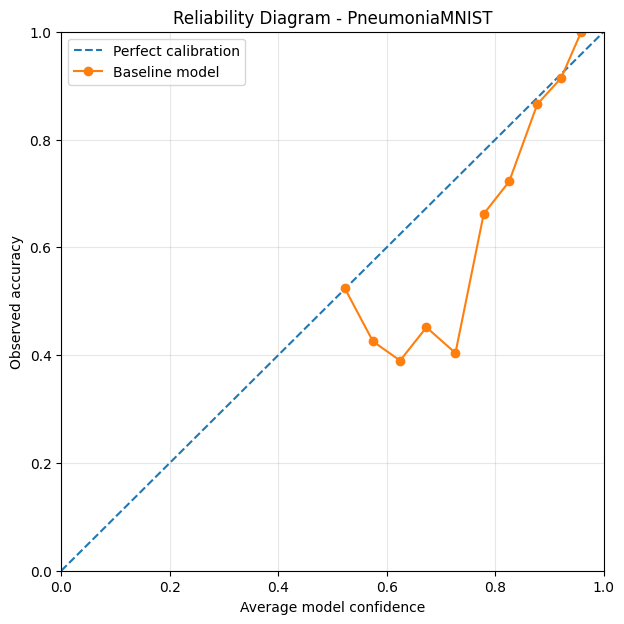

In [19]:
# A reliability diagram compares:
#
#   Model confidence  <->  Actual accuracy
#
# If a model is perfectly calibrated, the points should
# sit close to the diagonal line.
#
# For example:
#   0.80 confidence -> approximately 0.80 actual accuracy
#
# Points below the diagonal indicate overconfidence:
# the model is more confident than its actual accuracy justifies.

confidence_values = [
    result["confidence"]
    for result in calibration_bins
]

accuracy_values = [
    result["accuracy"]
    for result in calibration_bins
]


# Create the figure.
plt.figure(figsize=(7, 7))


# Draw the ideal calibration line.
# Every point on this line represents perfect calibration.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)


# Plot the model's actual calibration behaviour.
plt.plot(
    confidence_values,
    accuracy_values,
    marker="o",
    label="Baseline model"
)


# Label the axes in plain language.
plt.xlabel("Average model confidence")
plt.ylabel("Observed accuracy")

plt.title("Reliability Diagram - PneumoniaMNIST")


# Keep both axes between 0 and 1 because
# confidence and accuracy are probabilities.
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

# 19. Display the ECE value

This repeats the final ECE value in a compact form so that it is easy to identify when reviewing the notebook output.


In [20]:
print(f"Expected Calibration Error (ECE): {ece:.4f}")

Expected Calibration Error (ECE): 0.1114


## Stage 1 Baseline Result

The initial SmallCNN baseline was trained for five epochs on PneumoniaMNIST.

### Test-set results

| Metric | Result |
|---|---:|
| Accuracy | 0.6538 |
| Precision | 0.6505 |
| Recall | 0.9641 |
| F1 score | 0.7769 |
| AUROC | 0.7861 |
| Brier score | 0.2071 |
| Expected Calibration Error (ECE) | 0.1114 |

### Initial observation

The model achieved substantially higher recall than precision and accuracy. This is consistent with the model producing a relatively large number of pneumonia predictions in a dataset where pneumonia is the majority class.

The reliability diagram showed noticeable deviation from the diagonal, particularly across several intermediate-confidence ranges. In these ranges, the model's reported confidence was higher than its observed accuracy, indicating overconfidence.

The highest-confidence predictions were closer to the diagonal than several intermediate-confidence groups.

### Interpretation

The baseline provides evidence that classification performance and confidence quality should be treated as separate evaluation questions. The model has measurable discriminative ability, but its confidence estimates are not consistently aligned with observed accuracy.

### Limitation

This is a small baseline experiment using PneumoniaMNIST and a simple convolutional neural network. The result should not be interpreted as evidence about clinical performance or real-world hospital deployment.

# 20. Separator before the controlled image-shift experiment

The baseline experiment is complete.

The next section does not retrain the model. Instead, it deliberately changes the appearance of the test images by reducing their contrast and then evaluates the same trained model again.


#### ===============================================================================================================================================

# 21. Create the controlled reduced-contrast dataset

This experiment changes only the input images.

The trained model remains exactly the same. A contrast factor of 0.5 is used to create a simple, controlled visual change to the test set.

This is intended as a basic stress test for sensitivity to image appearance, not as a complete simulation of clinical distribution shift.


In [21]:
# We will create a controlled change to the test images by
# modifying their contrast.
#
# IMPORTANT:
# We are NOT changing the trained model.
# We are only changing the input images.
#
# This lets us ask whether a model trained on one type of
# image appearance behaves differently when the appearance changes.

from PIL import Image, ImageEnhance


def create_contrast_shifted_dataset(dataset, contrast_factor=0.5):
    """
    Create a modified version of a dataset by changing image contrast.

    contrast_factor:
        1.0 = original contrast
        below 1.0 = reduced contrast
        above 1.0 = increased contrast

    We use reduced contrast as a simple controlled stress test.
    """

    shifted_images = []
    labels = []

    # Go through every image in the supplied dataset.
    for i in range(len(dataset)):

        # Get the original image and its label.
        image_tensor, label = dataset[i]

        # Convert the tensor back into a standard image.
        #
        # The tensor contains values between 0 and 1,
        # so we first convert it into the 0-255 range
        # expected by PIL.
        image_array = (
            image_tensor.squeeze().numpy() * 255
        ).astype(np.uint8)

        image_pil = Image.fromarray(
            image_array,
            mode="L"
        )

        # Change the image contrast.
        enhancer = ImageEnhance.Contrast(image_pil)

        shifted_image = enhancer.enhance(
            contrast_factor
        )

        # Convert the modified image back into a tensor.
        shifted_array = (
            np.asarray(shifted_image).astype(np.float32) / 255.0
        )

        shifted_tensor = torch.tensor(
            shifted_array
        ).unsqueeze(0)

        shifted_images.append(shifted_tensor)
        labels.append(
            int(np.asarray(label).squeeze())
        )

    # Combine all individual tensors into one dataset tensor.
    shifted_images = torch.stack(
        shifted_images
    )

    labels = torch.tensor(labels)

    return shifted_images, labels

# 22. Generate the reduced-contrast test set

The contrast-shift function is now applied to the complete test set.

The labels are kept unchanged because only the image appearance is being modified.


In [22]:
# Create a lower-contrast version of the complete test set.
#
# A factor of 0.5 means we are deliberately reducing the
# contrast to create a controlled visual change.
shifted_test_images, shifted_test_labels = (
    create_contrast_shifted_dataset(
        test_ds,
        contrast_factor=0.5
    )
)


print(
    "Shifted test images:",
    shifted_test_images.shape
)

print(
    "Shifted test labels:",
    shifted_test_labels.shape
)

Shifted test images: torch.Size([624, 1, 64, 64])
Shifted test labels: torch.Size([624])


# 23. Visually verify the contrast shift

Before evaluating the model, I compare original and reduced-contrast images side by side.

This is an important sanity check because I want to confirm that the intended input change actually occurred before interpreting any changes in model behaviour.


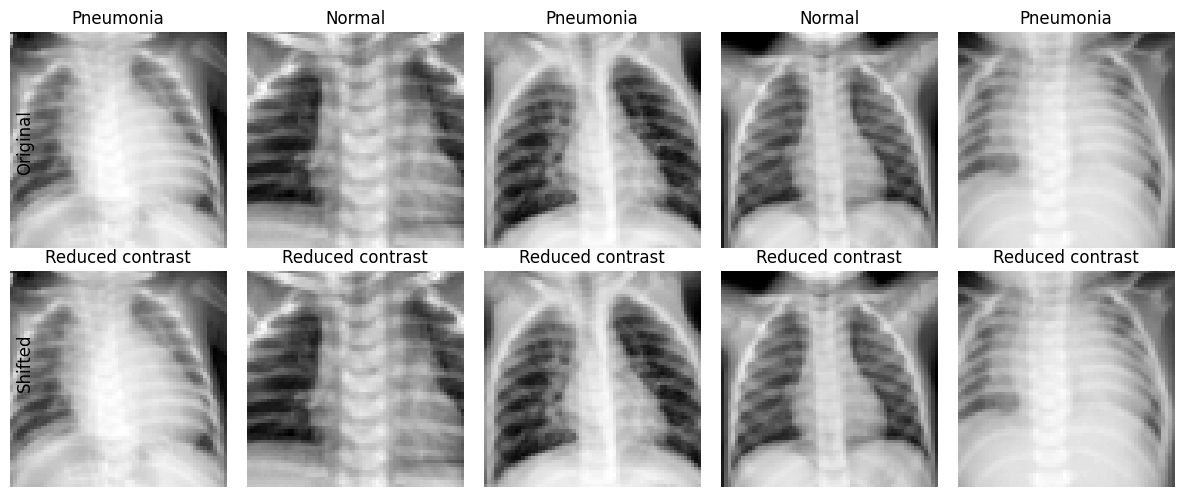

In [23]:
# We will compare the original X-rays with their lower-contrast
# versions side by side.
#
# This is an important sanity check:
# before measuring the model's response to a distribution shift,
# we should confirm that the input images were actually changed.

fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5)
)


# Select five examples from the test dataset.
# Using fixed indices makes the comparison reproducible.
example_indices = [0, 1, 2, 3, 4]


for column, idx in enumerate(example_indices):

    # ---------------------------------------------------------
    # ORIGINAL IMAGE
    # ---------------------------------------------------------

    original_image, original_label = test_ds[idx]

    # Convert the label from its NumPy-array representation
    # into a simple integer.
    label_value = int(
        np.asarray(original_label).squeeze()
    )

    # Display the original image.
    axes[0, column].imshow(
        original_image.squeeze(),
        cmap="gray"
    )

    axes[0, column].set_title(
        "Pneumonia" if label_value == 1 else "Normal"
    )

    axes[0, column].axis("off")


    # ---------------------------------------------------------
    # SHIFTED IMAGE
    # ---------------------------------------------------------

    # Retrieve the corresponding lower-contrast image
    # that we created earlier.
    shifted_image = shifted_test_images[idx]

    # Display the shifted version.
    axes[1, column].imshow(
        shifted_image.squeeze(),
        cmap="gray"
    )

    axes[1, column].set_title(
        "Reduced contrast"
    )

    axes[1, column].axis("off")


# Add labels to the two rows so that the comparison
# is immediately understandable.
fig.text(
    0.02,
    0.72,
    "Original",
    rotation="vertical",
    va="center",
    fontsize=12
)

fig.text(
    0.02,
    0.28,
    "Shifted",
    rotation="vertical",
    va="center",
    fontsize=12
)


plt.tight_layout()
plt.show()

# 24. Run the trained model on the shifted images

The same trained SmallCNN is now run on the reduced-contrast test set.

No training or parameter updates occur in this section. The only difference from the original evaluation is the input image appearance.


In [24]:
# Create a DataLoader for the reduced-contrast test images.
#
# We are using the same batch size as before so that the original
# and shifted test evaluations are directly comparable.
shifted_test_loader = DataLoader(
    list(zip(shifted_test_images, shifted_test_labels)),
    batch_size=128,
    shuffle=False
)


def collect_shifted_predictions(model, data_loader):
    """
    Run the already-trained model on the shifted test images.

    Important:
    We are NOT training or updating the model here.

    The purpose is to see how the same model behaves when the
    appearance of its input images has been changed.
    """

    # Put the model into evaluation mode because we are only
    # making predictions.
    model.eval()

    all_logits = []
    all_probabilities = []
    all_labels = []

    # We don't need gradients because the model is not being trained.
    with torch.no_grad():

        for images, labels in data_loader:

            # Move the images to the same device as the model.
            images = images.to(device)

            # Ask the original trained model to make predictions.
            logits = model(images)

            # Convert the raw model scores into probabilities.
            probabilities = torch.sigmoid(logits)

            # Store the predictions and labels so that we can
            # calculate the evaluation metrics after all batches
            # have been processed.
            all_logits.append(
                logits.cpu().numpy()
            )

            all_probabilities.append(
                probabilities.cpu().numpy()
            )

            all_labels.append(
                labels.numpy().squeeze()
            )


    # Combine the batches into one complete set of predictions.
    all_logits = np.concatenate(all_logits)
    all_probabilities = np.concatenate(all_probabilities)
    all_labels = np.concatenate(all_labels)

    return (
        all_logits,
        all_probabilities,
        all_labels
    )


# Run the trained model on the reduced-contrast images.
shifted_logits, shifted_probabilities, shifted_labels = (
    collect_shifted_predictions(
        model,
        shifted_test_loader
    )
)


print(
    "Shifted predictions:",
    len(shifted_probabilities)
)

Shifted predictions: 624


# 25. Compare individual probabilities before and after the shift

For the same examples, I compare the original pneumonia probability with the probability produced after reducing image contrast.

This gives an intuitive view of whether the controlled input change affects model confidence.


In [25]:
# Compare the model's pneumonia probability for the same
# images before and after the contrast shift.
#
# This lets us see whether changing only the image appearance
# changes the model's confidence.

for i in range(10):

    actual = (
        "Pneumonia"
        if test_labels[i] == 1
        else "Normal"
    )

    print(
        f"Example {i + 1}: "
        f"Actual = {actual} | "
        f"Original probability = {test_probabilities[i]:.3f} | "
        f"Shifted probability = {shifted_probabilities[i]:.3f}"
    )

Example 1: Actual = Pneumonia | Original probability = 0.790 | Shifted probability = 0.884
Example 2: Actual = Normal | Original probability = 0.847 | Shifted probability = 0.939
Example 3: Actual = Pneumonia | Original probability = 0.772 | Shifted probability = 0.919
Example 4: Actual = Normal | Original probability = 0.541 | Shifted probability = 0.817
Example 5: Actual = Pneumonia | Original probability = 0.905 | Shifted probability = 0.949
Example 6: Actual = Pneumonia | Original probability = 0.927 | Shifted probability = 0.956
Example 7: Actual = Pneumonia | Original probability = 0.928 | Shifted probability = 0.959
Example 8: Actual = Pneumonia | Original probability = 0.961 | Shifted probability = 0.970
Example 9: Actual = Pneumonia | Original probability = 0.797 | Shifted probability = 0.906
Example 10: Actual = Normal | Original probability = 0.690 | Shifted probability = 0.874


# 26. Calculate metrics for the reduced-contrast test set

The shifted test set is evaluated using the same metrics as the original test set.

Using the same definitions and the same 0.5 decision threshold keeps the comparison between the original and shifted inputs consistent.


In [26]:
# Convert the pneumonia probabilities into class predictions.
#
# We use exactly the same 0.5 decision threshold as we used
# for the original test set. This keeps the comparison fair:
#
# probability >= 0.5 -> Pneumonia
# probability < 0.5  -> Normal
shifted_predictions = (
    shifted_probabilities >= 0.5
).astype(int)


# ---------------------------------------------------------
# CLASSIFICATION PERFORMANCE
# ---------------------------------------------------------

# Accuracy:
# What percentage of all shifted X-rays did the model
# classify correctly?
shifted_accuracy = accuracy_score(
    shifted_labels,
    shifted_predictions
)


# Precision:
# When the model predicted pneumonia, how often was
# the actual label pneumonia?
shifted_precision = precision_score(
    shifted_labels,
    shifted_predictions,
    zero_division=0
)


# Recall:
# Of all actual pneumonia cases, how many did the
# model successfully identify?
shifted_recall = recall_score(
    shifted_labels,
    shifted_predictions,
    zero_division=0
)


# F1 score:
# Combines precision and recall into one measure.
shifted_f1 = f1_score(
    shifted_labels,
    shifted_predictions,
    zero_division=0
)


# AUROC:
# Measures how well the model ranks pneumonia cases above
# normal cases across many possible decision thresholds.
shifted_auroc = roc_auc_score(
    shifted_labels,
    shifted_probabilities
)


# ---------------------------------------------------------
# PROBABILITY QUALITY
# ---------------------------------------------------------

# Brier score:
# Measures the quality of the probability predictions themselves.
#
# Lower is better.
shifted_brier = brier_score_loss(
    shifted_labels,
    shifted_probabilities
)


# Expected Calibration Error:
# Measures how closely the model's confidence agrees with
# its observed correctness.
#
# We use exactly the same function and number of bins that
# we used for the original test set.
shifted_ece, shifted_calibration_bins = calculate_ece(
    shifted_probabilities,
    shifted_labels,
    number_of_bins=10
)


# ---------------------------------------------------------
# DISPLAY THE RESULTS
# ---------------------------------------------------------

print("Reduced-Contrast Test Results")
print("-----------------------------")

print(f"Accuracy : {shifted_accuracy:.4f}")
print(f"Precision: {shifted_precision:.4f}")
print(f"Recall   : {shifted_recall:.4f}")
print(f"F1 Score : {shifted_f1:.4f}")
print(f"AUROC    : {shifted_auroc:.4f}")
print(f"Brier    : {shifted_brier:.4f}")
print(f"ECE      : {shifted_ece:.4f}")

Reduced-Contrast Test Results
-----------------------------
Accuracy : 0.6170
Precision: 0.6240
Recall   : 0.9744
F1 Score : 0.7608
AUROC    : 0.6909
Brier    : 0.2828
ECE      : 0.2534


# 27. Compare the original and shifted results

The final comparison places the original and reduced-contrast results side by side.

The change column shows the numerical difference caused by the controlled contrast modification.


In [27]:
# Put the original and shifted results next to each other.
#
# This makes it much easier to see what changed when we altered
# only the contrast of the test images.

print("Original vs Reduced-Contrast Test Set")
print("--------------------------------------")

print(
    f"{'Metric':<12}"
    f"{'Original':>12}"
    f"{'Shifted':>12}"
    f"{'Change':>12}"
)

print("-" * 48)


# Store all metrics in one place so that we do not have to
# manually repeat the print statement for every measurement.
comparison = [
    ("Accuracy", accuracy, shifted_accuracy),
    ("Precision", precision, shifted_precision),
    ("Recall", recall, shifted_recall),
    ("F1", f1, shifted_f1),
    ("AUROC", auroc, shifted_auroc),
    ("Brier", brier, shifted_brier),
    ("ECE", ece, shifted_ece)
]


for metric_name, original_value, shifted_value in comparison:

    # Calculate the numerical difference caused by the shift.
    change = shifted_value - original_value

    print(
        f"{metric_name:<12}"
        f"{original_value:>12.4f}"
        f"{shifted_value:>12.4f}"
        f"{change:>+12.4f}"
    )

Original vs Reduced-Contrast Test Set
--------------------------------------
Metric          Original     Shifted      Change
------------------------------------------------
Accuracy          0.6538      0.6170     -0.0369
Precision         0.6505      0.6240     -0.0265
Recall            0.9641      0.9744     +0.0103
F1                0.7769      0.7608     -0.0161
AUROC             0.7861      0.6909     -0.0951
Brier             0.2071      0.2828     +0.0757
ECE               0.1114      0.2534     +0.1420


# Stage 1 Findings: Baseline Performance and Controlled Image Shift

The first experiment establishes a simple convolutional neural network (CNN) baseline on PneumoniaMNIST and examines how its predictions change when the test images are subjected to a controlled reduction in contrast.

The model was trained for five epochs using the training split, while the validation split was kept separate for development and later calibration experiments. The training loss decreased from 0.5903 to 0.4845, while the validation loss decreased from 0.5673 to 0.4497. This suggests that the model was learning useful patterns from the training data without showing an obvious increase in validation loss during these five epochs.

### Baseline test performance

On the original PneumoniaMNIST test set, the model achieved:

- Accuracy: 0.6538
- Precision: 0.6505
- Recall: 0.9641
- F1 score: 0.7769
- AUROC: 0.7861
- Brier score: 0.2071
- Expected Calibration Error (ECE): 0.1114

The results show that the model has useful discriminative ability, with an AUROC of 0.7861, but it also has a strong tendency to predict pneumonia. This is reflected in the high recall of 0.9641 compared with the lower precision of 0.6505.

The calibration analysis also shows that the model's confidence does not always correspond closely to its observed accuracy. In several confidence ranges, the model reported substantially higher confidence than the proportion of correct predictions. This indicates that the baseline model is not perfectly calibrated even on the original test distribution.

### Controlled reduced-contrast experiment

To examine sensitivity to a simple change in image appearance, the contrast of every test image was reduced by a factor of 0.5. The trained model and the labels were kept unchanged. This provides a controlled stress test in which the input appearance is changed while the underlying class labels remain the same.

After the contrast reduction, performance changed as follows:

- Accuracy decreased from 0.6538 to 0.6170.
- Precision decreased from 0.6505 to 0.6240.
- F1 score decreased from 0.7769 to 0.7608.
- AUROC decreased from 0.7861 to 0.6909.
- Brier score increased from 0.2071 to 0.2828.
- ECE increased from 0.1114 to 0.2534.

Recall remained high, increasing slightly from 0.9641 to 0.9744.

The most important observation is that the reduction in contrast affected both classification performance and probability quality. The decrease in AUROC suggests that the model became less effective at separating normal and pneumonia cases. At the same time, the increase in Brier score and ECE indicates that the model's probability estimates became less reliable.

Interestingly, several examples also showed the model becoming more confident after the contrast reduction, even when the prediction was incorrect. For example, one normal image changed from a pneumonia probability of 0.541 to 0.817 after the contrast shift. This suggests that the model can become more confident under a changed image appearance without becoming more correct.

### What this experiment tells us

This experiment provides an initial indication that model performance and confidence can both deteriorate when the input image distribution is changed. Importantly, the effect is not limited to classification accuracy. The calibration measures show that the model's confidence can become less aligned with its actual correctness under the shifted condition.

This is relevant to trustworthy medical AI because a model that produces highly confident predictions under changed conditions may be more difficult to use safely than a model that communicates uncertainty appropriately.

### Limitation of the Stage 1 experiment

The contrast reduction used here is a controlled synthetic perturbation. It is useful for demonstrating sensitivity to a change in image appearance, but it does not represent the full range of distribution shifts that can occur between hospitals or clinical settings.

For example, this experiment does not directly test changes in scanners, acquisition protocols, patient populations, clinical workflows, or other sources of external dataset variation.

Therefore, the Stage 1 result should be treated as an initial stress test rather than evidence of general clinical robustness.

The next stage addresses this limitation by evaluating the same trained model on an independently sourced chest X-ray dataset.

### Next experiment: Temperature Scaling